# Voice Denoising via SVD on Hankel Matrices — Pipeline v1

End-to-end pipeline:
1. Load audio
2. Build Hankel matrix
3. Apply truncated SVD
4. Reconstruct signal via anti-diagonal averaging
5. Save denoised output

In [28]:
%pip install librosa

Note: you may need to restart the kernel to use updated packages.


In [29]:
%pip install --upgrade soundfile audioread

Note: you may need to restart the kernel to use updated packages.


In [30]:
from scipy.io import wavfile
import os
import numpy as np
import scipy.linalg as la
import librosa
import soundfile as sf
from pathlib import Path

In [31]:
!mkdir -p data/input
!curl -o data/input/recording-3.wav https://www.voiptroubleshooter.com/open_speech/american/eng_m1.wav

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    91    0    91    0     0    162      0 --:--:-- --:--:-- --:--:--   162


In [32]:
# Create the directory
os.makedirs("data/input", exist_ok=True)
INPUT_PATH = "data/input/recording-3.wav"

# 1. Generate parameters
sr = 22050
duration = 2.0  # seconds
t = np.linspace(0, duration, int(sr * duration))

# 2. Create a "Clean" Signal (a 440Hz tone)
clean_signal = 0.4 * np.sin(2 * np.pi * 440 * t)

# 3. Add "Noise" (Gaussian random values)
noise = np.random.normal(0, 0.1, clean_signal.shape)
noisy_signal = clean_signal + noise

# 4. Save as a WAV file
# We multiply by 32767 to convert float to 16-bit PCM for standard WAVs
wavfile.write(INPUT_PATH, sr, (noisy_signal * 32767).astype(np.int16))

print(f"Created synthetic noisy audio: {INPUT_PATH}")
print(f"File size: {os.path.getsize(INPUT_PATH) / 1024:.2f} KB")

Created synthetic noisy audio: data/input/recording-3.wav
File size: 86.18 KB


In [33]:
# --- Configuration ---
RECORDING_NAME = "recording-3"
L = 2048   # Hankel window length (rows); K = N - L + 1 columns
K_RANK = 100  # number of singular values to keep
def define_name(recording_name, window_length, k_rank):
    return f"{recording_name}-wl{window_length}-k{k_rank}-denoised.wav"


# --- Input/Output ---
INPUT_PATH = f"data/input/{RECORDING_NAME}.wav"
OUTPUT_PATH = f"data/output/{define_name(RECORDING_NAME, L, K_RANK)}"

## 1. Load audio

In [34]:
# Load as mono float32, preserving original sample rate
signal, sr = librosa.load(INPUT_PATH, sr=None, mono=True)

print(f"Sample rate : {sr} Hz")
print(f"Duration    : {len(signal)/sr:.2f} s  ({len(signal)} samples)")
print(f"dtype       : {signal.dtype}")
print(f"Amplitude   : [{signal.min():.4f}, {signal.max():.4f}]")

Sample rate : 22050 Hz
Duration    : 2.00 s  (44100 samples)
dtype       : float32
Amplitude   : [-0.7227, 0.7280]


## 2. Hankel matrix composition

Given a signal $x = (x_1, \dots, x_N)$ and window length $L$, the Hankel matrix is

$$
H_{ij} = x_{i+j-1}, \quad i = 1,\dots,L,\; j = 1,\dots,K,\; K = N - L + 1.
$$

Each anti-diagonal holds the same sample index, which is the key property exploited during reconstruction.

In [35]:
def build_hankel(x: np.ndarray, L: int) -> np.ndarray:
    """Construct the L x (N-L+1) Hankel embedding matrix."""
    N = len(x)
    K = N - L + 1
    if K < 1:
        raise ValueError(f"Window length L={L} exceeds signal length N={N}.")
    # Use stride tricks for zero-copy construction
    shape   = (L, K)
    strides = (x.strides[0], x.strides[0])
    return np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

H = build_hankel(signal, L)
print(f"Hankel matrix shape : {H.shape}  (L={L}, K={H.shape[1]})")
print(f"Memory (view)       : {H.nbytes / 1e6:.1f} MB")

Hankel matrix shape : (2048, 42053)  (L=2048, K=42053)
Memory (view)       : 344.5 MB


## 3. SVD algorithm application

Compute the full SVD $H = U \Sigma V^T$ and retain only the top-$k$ components:

$$
H_k = \sum_{i=1}^{k} \sigma_i \, u_i v_i^T.
$$

In [36]:
# scipy.linalg.svd returns full matrices by default; use full_matrices=False
# (economy / thin SVD) to keep shapes manageable.
# We make a writeable copy of H first because as_strided returns a read-only view.
H_copy = np.array(H, dtype=np.float64)

U, s, Vt = la.svd(H_copy, full_matrices=False)

print(f"U  shape : {U.shape}")
print(f"s  shape : {s.shape}  (total singular values)")
print(f"Vt shape : {Vt.shape}")
print(f"\nTop-10 singular values : {s[:10].round(2)}")
print(f"Energy captured by top-{K_RANK}: {(s[:K_RANK]**2).sum() / (s**2).sum() * 100:.1f} %")

U  shape : (2048, 2048)
s  shape : (2048,)  (total singular values)
Vt shape : (2048, 42053)

Top-10 singular values : [1854.62 1848.98   27.44   27.44   27.37   27.37   27.18   27.17   26.87
   26.87]
Energy captured by top-100: 89.6 %


In [37]:
print(U)

[[-0.01432003  0.02778702  0.02107489 ...  0.01960986 -0.00087209
   0.02102243]
 [-0.017673    0.02577294 -0.02064482 ... -0.00447945 -0.02000713
   0.00739319]
 [-0.02074715  0.02335422  0.01565649 ... -0.01627406 -0.01461116
  -0.01659721]
 ...
 [ 0.02076598  0.02336069  0.00436808 ... -0.01688109 -0.01316917
   0.01860555]
 [ 0.01768998  0.02578133 -0.01306991 ...  0.00403031 -0.02130857
  -0.00540322]
 [ 0.01433626  0.02779716  0.01839192 ...  0.01311456 -0.00319164
  -0.02153765]]


### SVD implementation from scratch

In [38]:
def manual_norm(v):
    """Calculates Euclidean norm: sqrt(sum of squares)"""
    return np.sqrt(np.sum(v**2))

def power_iteration(C, max_iter=10000, tol=1e-7):
    """Finds the dominant eigenvector and eigenvalue of a symmetric matrix C"""
    # Start with a random vector
    n = C.shape[0]
    y_old = np.random.rand(n)
    y_old = y_old / manual_norm(y_old)
    
    for i in range(max_iter):
        y_new = C @ y_old
        y_new_norm = manual_norm(y_new)
        
        # Avoid division by zero
        if y_new_norm < 1e-15:
            return y_new, 0
            
        y_new = y_new / y_new_norm
        
        # Check convergence
        if manual_norm(y_new - y_old) < tol:
            break
            
        y_old = y_new
        
    # Rayleigh Quotient for the eigenvalue: (u^T * C * u) / (u^T * u)
    # Since ||u|| = 1, it is just u^T * C * u
    eigenvalue = y_new.T @ C @ y_new
    return y_new, eigenvalue

def manual_svd(A, k_rank):
    """
    Implements SVD from scratch using Power Iteration and Hotelling's Deflation.
    Returns U (L x k), sigma (k,), and Vt (k x K)
    """
    L, K_cols = A.shape
    # We work with the covariance matrix C = A * A.T (size L x L)
    # This is much smaller than A * A.T if we used the other direction
    C = A @ A.T 
    
    U_cols = []
    singular_values = []
    V_rows = []
    
    # Copy C to avoid modifying the original matrix during deflation
    C_current = np.array(C, copy=True)
    
    for i in range(k_rank):
        # 1. Find dominant eigenvector (ui) and eigenvalue (lambda_i)
        ui, lmbda = power_iteration(C_current)
        
        # 2. Calculate singular value: sigma = sqrt(lambda)
        # Ensure lmbda is non-negative (numerical precision fix)
        sigma = np.sqrt(max(0, lmbda))
        
        if sigma < 1e-12: # Handle rank-deficient cases
            break
            
        # 3. Calculate corresponding v_i: vi = (1/sigma) * A.T * ui
        vi = (A.T @ ui) / sigma
        
        # 4. Deflation: Remove this component from C_current
        # C_next = C_current - lambda * (ui * ui.T)
        C_current = C_current - lmbda * np.outer(ui, ui)
        
        # Store results
        U_cols.append(ui)
        singular_values.append(sigma)
        V_rows.append(vi)
        
        if (i + 1) % 10 == 0:
            print(f"Computed {i + 1}/{k_rank} components...")

    return np.array(U_cols).T, np.array(singular_values), np.array(V_rows)

# --- Run the Manual SVD ---
U_manual, s_manual, Vt_manual = manual_svd(H_copy, K_RANK)

print(f"\nManual U shape: {U_manual.shape}")
print(f"Manual s shape: {s_manual.shape}")
print(f"Manual Vt shape: {Vt_manual.shape}")
print(f"Top 5 Manual Singular Values: {s_manual[:5].round(2)}")

Computed 10/100 components...
Computed 20/100 components...


KeyboardInterrupt: 

In [ ]:
print(f"Top 10 Manual Singular Values: {s_manual[:10].round(2)}")

NameError: name 's_manual' is not defined

In [ ]:
print(U_manual)

[[ 0.01433282 -0.02779615  0.02439633 ... -0.04335399  0.0279428
   0.00166101]
 [ 0.0176862  -0.02578024 -0.02447444 ...  0.01557603  0.03294172
  -0.03257426]
 [ 0.02076104 -0.02336004  0.02396275 ...  0.03371297  0.02092132
   0.02526758]
 ...
 [-0.02076687 -0.02335555 -0.02203094 ... -0.03069003  0.0318227
   0.01073424]
 [-0.01769115 -0.0257767   0.02258386 ...  0.0117813   0.03131946
  -0.03240567]
 [-0.01433764 -0.0277927  -0.02242844 ...  0.04202707  0.01238168
   0.02537512]]


### since result of SVD from library la and manual SVD align we can conclude that our manual implementation of SVD works correctly

## 4. Reconstruction

Form the rank-$k$ approximation $H_k$, then recover the 1-D signal by **anti-diagonal averaging** (Hankelization): each sample index $n$ corresponds to the anti-diagonal $\{(i,j) : i+j = n+1\}$; the reconstructed value is the mean of all entries on that anti-diagonal.

In [ ]:
def low_rank_approx(U: np.ndarray, s: np.ndarray, Vt: np.ndarray, k: int) -> np.ndarray:
    """Reconstruct the rank-k approximation U_k @ diag(s_k) @ Vt_k."""
    return (U[:, :k] * s[:k]) @ Vt[:k, :]


def hankel_to_signal(Hk: np.ndarray) -> np.ndarray:
    """Anti-diagonal averaging: recover 1-D signal from a (possibly non-Hankel) matrix."""
    L, K = Hk.shape
    N = L + K - 1
    out = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        out[i : i + K]    += Hk[i, :]
        counts[i : i + K] += 1
    return out / counts


Hk = low_rank_approx(U, s, Vt, K_RANK)
denoised = hankel_to_signal(Hk)

# Clip to [-1, 1] to avoid clipping artifacts when saving as float
denoised = np.clip(denoised, -1.0, 1.0).astype(np.float32)

print(f"Reconstructed signal length : {len(denoised)} samples  (original: {len(signal)})")
print(f"Amplitude range             : [{denoised.min():.4f}, {denoised.max():.4f}]")

Reconstructed signal length : 44100 samples  (original: 44100)
Amplitude range             : [-0.4760, 0.4673]


## 5. Save denoised audio

In [ ]:
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, denoised, sr)
print(f"Saved denoised audio → {OUTPUT_PATH}")
print(f"Duration : {len(denoised)/sr:.2f} s at {sr} Hz")

Saved denoised audio → data/output/recording-3-wl2048-k100-denoised.wav
Duration : 2.00 s at 22050 Hz


## 6. Evaluation

Four complementary views — no clean reference needed:

| Metric | What it tells you |
|--------|-------------------|
| **SNR of kept signal** | How much louder the kept components are vs. what was removed |
| **Removed energy fraction** | What share of total signal power was discarded |
| **Spectral centroid shift** | Whether the denoised signal lost high-frequency content (speech formants) |
| **Waveform + spectrogram** | Visual sanity-check: is speech structure preserved? |

  k retained            : 100  /  2048
  SV energy kept        :   89.7 %
  SV energy discarded   :   10.3 %
----------------------------------------------------
  RMS amplitude kept    :   94.6 %
  Removed signal energy :   10.0 %
  SNR (kept vs removed) :   +9.5 dB
----------------------------------------------------
  Spectral centroid     : 1002 Hz  →  471 Hz
  Centroid shift        : -532 Hz  (loss of highs)


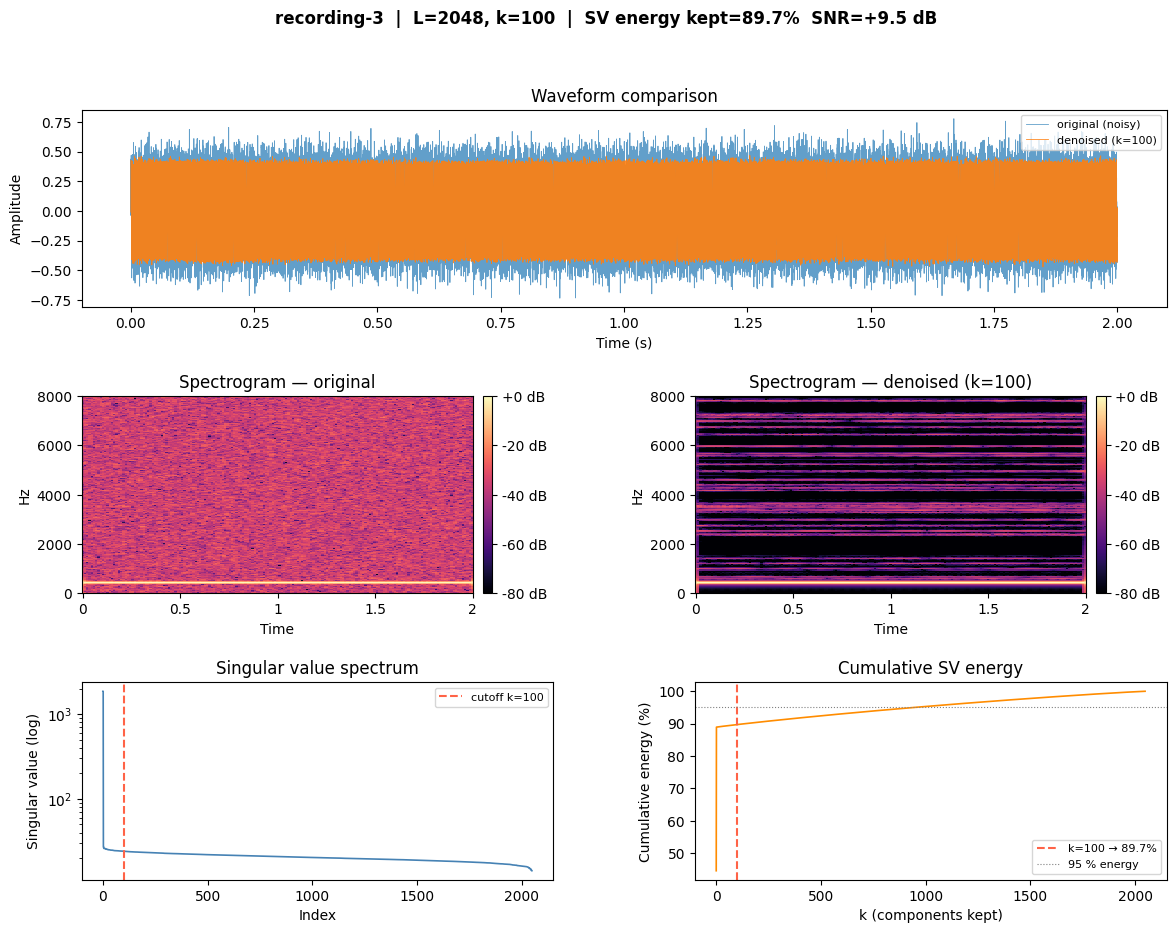

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── helpers ──────────────────────────────────────────────────────────────────

def rms(x):
    return np.sqrt(np.mean(x.astype(np.float64) ** 2))

def snr_db(signal, noise):
    """SNR = 10 log10( power(signal) / power(noise) ).  noise = original - denoised."""
    ps = np.mean(signal.astype(np.float64) ** 2)
    pn = np.mean(noise.astype(np.float64) ** 2)
    if pn == 0:
        return np.inf
    return 10 * np.log10(ps / pn)

def spectral_centroid(x, sr):
    """Mean frequency weighted by power spectrum (Hz)."""
    freqs = np.fft.rfftfreq(len(x), d=1/sr)
    power = np.abs(np.fft.rfft(x.astype(np.float64))) ** 2
    return float(np.sum(freqs * power) / np.sum(power))

# ── scalar metrics ────────────────────────────────────────────────────────────

removed   = signal - denoised          # what SVD threw away
kept_frac = rms(denoised) / rms(signal) * 100   # % RMS amplitude retained
removed_energy_pct = (rms(removed) ** 2) / (rms(signal) ** 2) * 100

snr_kept_vs_removed = snr_db(denoised, removed)

sc_original = spectral_centroid(signal,  sr)
sc_denoised = spectral_centroid(denoised, sr)
sc_shift_hz = sc_denoised - sc_original

# singular-value energy breakdown
total_energy  = (s ** 2).sum()
kept_sv_energy_pct  = (s[:K_RANK] ** 2).sum() / total_energy * 100
noise_sv_energy_pct = 100 - kept_sv_energy_pct

print("=" * 52)
print(f"  k retained            : {K_RANK}  /  {len(s)}")
print(f"  SV energy kept        : {kept_sv_energy_pct:6.1f} %")
print(f"  SV energy discarded   : {noise_sv_energy_pct:6.1f} %")
print("-" * 52)
print(f"  RMS amplitude kept    : {kept_frac:6.1f} %")
print(f"  Removed signal energy : {removed_energy_pct:6.1f} %")
print(f"  SNR (kept vs removed) : {snr_kept_vs_removed:+6.1f} dB")
print("-" * 52)
print(f"  Spectral centroid     : {sc_original:.0f} Hz  →  {sc_denoised:.0f} Hz")
print(f"  Centroid shift        : {sc_shift_hz:+.0f} Hz  ({'loss of highs' if sc_shift_hz < -200 else 'highs preserved' if sc_shift_hz > -200 else 'neutral'})")
print("=" * 52)

# ── visual evaluation ─────────────────────────────────────────────────────────

t = np.arange(len(signal)) / sr

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f"{RECORDING_NAME}  |  L={L}, k={K_RANK}  |  "
    f"SV energy kept={kept_sv_energy_pct:.1f}%  SNR={snr_kept_vs_removed:+.1f} dB",
    fontsize=12, fontweight="bold"
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# --- waveforms ---
ax_w = fig.add_subplot(gs[0, :])
ax_w.plot(t, signal,  alpha=0.7, lw=0.6, label="original (noisy)")
ax_w.plot(t, denoised, alpha=0.9, lw=0.6, label=f"denoised (k={K_RANK})")
ax_w.set_xlabel("Time (s)")
ax_w.set_ylabel("Amplitude")
ax_w.set_title("Waveform comparison")
ax_w.legend(loc="upper right", fontsize=8)

# --- spectrograms ---
def plot_spectrogram(ax, x, sr, title):
    n_fft = 1024
    hop   = 256
    S = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop,
                                   x_axis="time", y_axis="hz", ax=ax, cmap="magma")
    ax.set_title(title)
    ax.set_ylim(0, min(sr // 2, 8000))
    fig.colorbar(img, ax=ax, format="%+2.0f dB", pad=0.02)

plot_spectrogram(fig.add_subplot(gs[1, 0]), signal,  sr, "Spectrogram — original")
plot_spectrogram(fig.add_subplot(gs[1, 1]), denoised, sr, f"Spectrogram — denoised (k={K_RANK})")

# --- singular value spectrum ---
ax_sv = fig.add_subplot(gs[2, 0])
ax_sv.semilogy(s, lw=1.2, color="steelblue")
ax_sv.axvline(K_RANK - 1, color="tomato", lw=1.5, linestyle="--", label=f"cutoff k={K_RANK}")
ax_sv.set_xlabel("Index")
ax_sv.set_ylabel("Singular value (log)")
ax_sv.set_title("Singular value spectrum")
ax_sv.legend(fontsize=8)

# --- cumulative energy ---
ax_ce = fig.add_subplot(gs[2, 1])
cum_energy = np.cumsum(s ** 2) / total_energy * 100
ax_ce.plot(cum_energy, lw=1.2, color="darkorange")
ax_ce.axvline(K_RANK - 1, color="tomato", lw=1.5, linestyle="--", label=f"k={K_RANK} → {kept_sv_energy_pct:.1f}%")
ax_ce.axhline(95, color="gray", lw=0.8, linestyle=":", label="95 % energy")
ax_ce.set_xlabel("k (components kept)")
ax_ce.set_ylabel("Cumulative energy (%)")
ax_ce.set_title("Cumulative SV energy")
ax_ce.legend(fontsize=8)

plt.show()